# 08 — Project1 Submission Dynamics: Seaborn Line Chart

## What this notebook does

Tracks how the number of submission attempts (`numTrials`) evolved over
time for each student during `project1`, visualized as individual lines
per user.

## Data

- **Source:** `checking-logs.sqlite` → table `checker`
- **Filtered:** only real students (`uid LIKE 'user_%'`), only `project1`,
  only successful submissions (`status = 'ready'`)
- **No aggregation:** raw submission timestamps and trial counts per user

## Key steps

1. Query `uid`, `timestamp` and `numTrials` for project1 submissions
2. Plot a multi-line chart using `sns.FacetGrid` with one line per user
3. Color each user differently using `hue='uid'`

## Result

A line chart showing how many attempts each student needed over time to
successfully submit project1. **user_4** had the highest number of trials
overall, while **user_2** submitted with the fewest attempts.

## Tools

`pandas` · `sqlite3` · `seaborn` · `matplotlib`

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/checking-logs.sqlite')

In [2]:
sea_data = pd.read_sql("""
                       SELECT c.uid, c.timestamp, c.numTrials
                       FROM checker AS c
                       WHERE c.labname = 'project1'
                       AND c.uid LIKE 'user_%'
                       AND status = 'ready'
                       """,
                       conn)
sea_data.head()

,uid,timestamp,numTrials
0,user_4,2020-04-17 05:19:02.744528,1
1,user_4,2020-04-17 05:22:45.549397,2
2,user_4,2020-04-17 05:34:24.422370,3
3,user_4,2020-04-17 05:43:27.773992,4
4,user_4,2020-04-17 05:46:32.275104,5


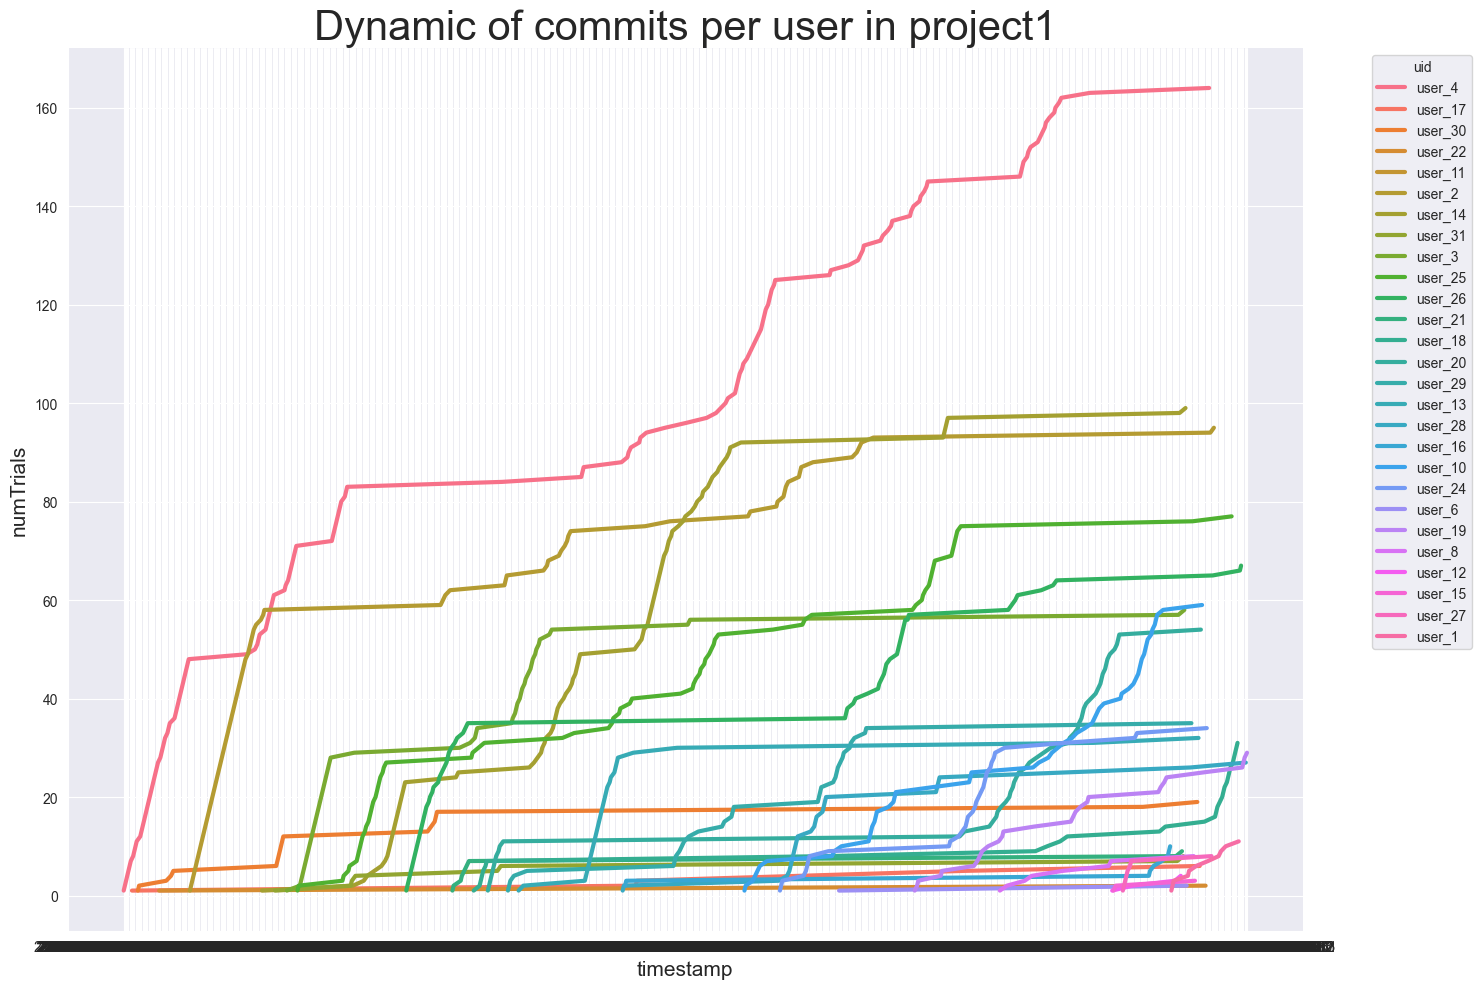

In [3]:
sns.set_style('darkgrid')

g = sns.FacetGrid(sea_data, height=10, aspect=1.5)
g.map_dataframe(sns.lineplot, x='timestamp', y='numTrials', hue='uid', linewidth=3)
g.ax.set_title('Dynamic of commits per user in project1', fontsize=30)
g.ax.set_xlabel('timestamp', fontsize=15)
g.ax.set_ylabel('numTrials', fontsize=15)
g.ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='uid')
plt.tight_layout()
plt.show()

In [4]:
conn.close()